<a href="https://colab.research.google.com/github/hrishikeshrprasad367/ML/blob/main/1BM23CS367_Lab_6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
drug=pd.read_csv("drug.csv")
iris=pd.read_csv("iris.csv")
petrol=pd.read_csv("petrol.csv")


In [3]:
drug.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
petrol.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [7]:
def plot_cm(cm, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

=== IRIS ===
Accuracy: 1.0


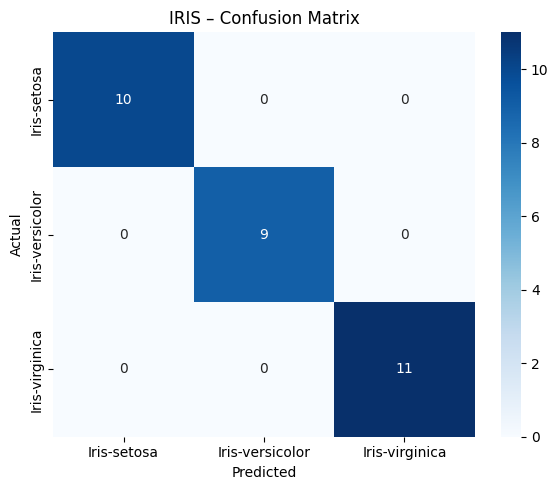

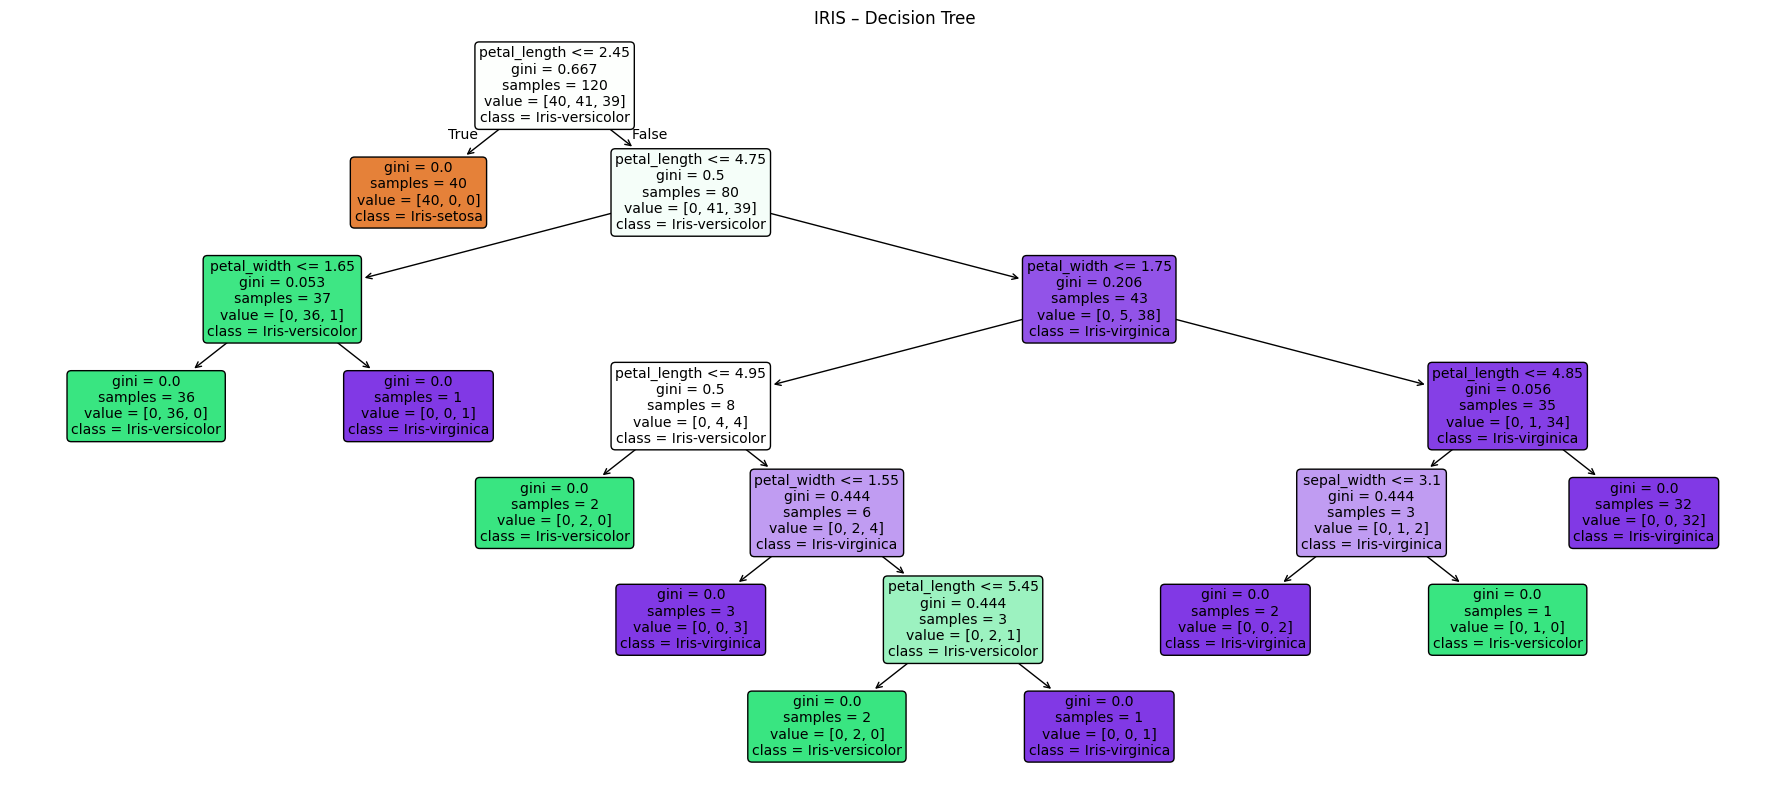

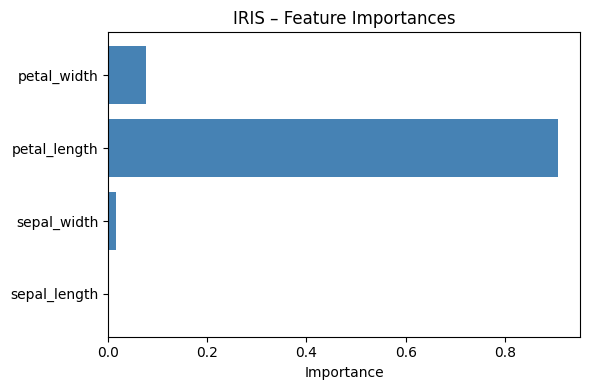

In [8]:
X_iris = iris.drop("species", axis=1)
y_iris = iris["species"]

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris,
                                           test_size=0.2, random_state=42)

clf_iris = DecisionTreeClassifier(random_state=42)
clf_iris.fit(X_tr, y_tr)
y_pred = clf_iris.predict(X_te)

print("=== IRIS ===")
print("Accuracy:", accuracy_score(y_te, y_pred))

cm_iris = confusion_matrix(y_te, y_pred)
plot_cm(cm_iris, clf_iris.classes_, "IRIS – Confusion Matrix")

# Decision Tree structure
plt.figure(figsize=(18, 8))
plot_tree(clf_iris, feature_names=X_iris.columns,
          class_names=clf_iris.classes_, filled=True, rounded=True)
plt.title("IRIS – Decision Tree")
plt.tight_layout()
plt.show()

# Feature importances
plt.figure(figsize=(6, 4))
plt.barh(X_iris.columns, clf_iris.feature_importances_, color="steelblue")
plt.xlabel("Importance")
plt.title("IRIS – Feature Importances")
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import LabelEncoder



=== DRUG ===
Accuracy: 1.0


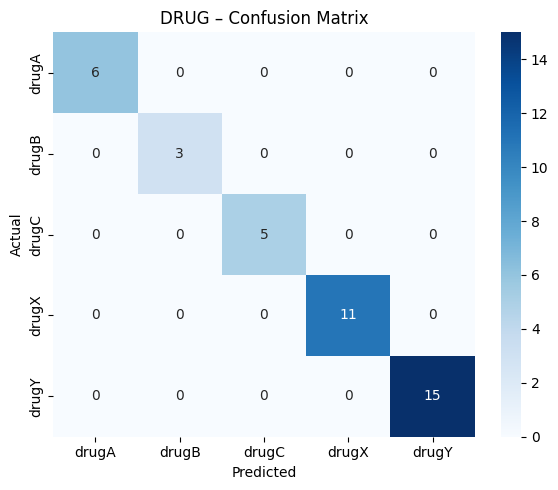

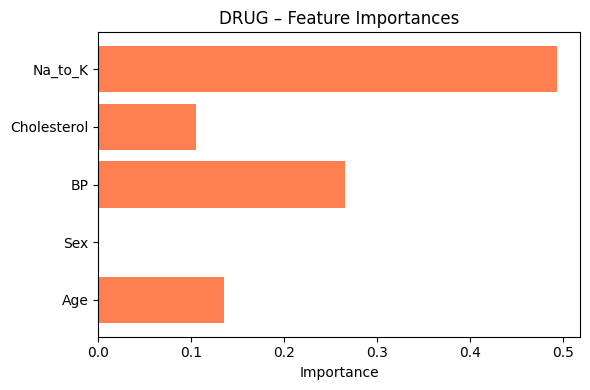

In [10]:
drug_enc = drug.copy()
le = LabelEncoder()
for col in ["Sex", "BP", "Cholesterol", "Drug"]:
    drug_enc[col] = le.fit_transform(drug_enc[col])

# keep a separate encoder for Drug labels
le_drug = LabelEncoder().fit(drug["Drug"])

X_drug = drug_enc.drop("Drug", axis=1)
y_drug = drug_enc["Drug"]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_drug, y_drug,
                                               test_size=0.2, random_state=42)

clf_drug = DecisionTreeClassifier(random_state=42)
clf_drug.fit(X_tr2, y_tr2)
y_pred2 = clf_drug.predict(X_te2)

print("\n=== DRUG ===")
print("Accuracy:", accuracy_score(y_te2, y_pred2))

cm_drug = confusion_matrix(y_te2, y_pred2)
plot_cm(cm_drug, le_drug.classes_, "DRUG – Confusion Matrix")

# Feature importances
plt.figure(figsize=(6, 4))
plt.barh(X_drug.columns, clf_drug.feature_importances_, color="coral")
plt.xlabel("Importance")
plt.title("DRUG – Feature Importances")
plt.tight_layout()
plt.show()


=== PETROL CONSUMPTION (Regression) ===
MAE : 94.30
MSE : 17347.70
RMSE: 131.71


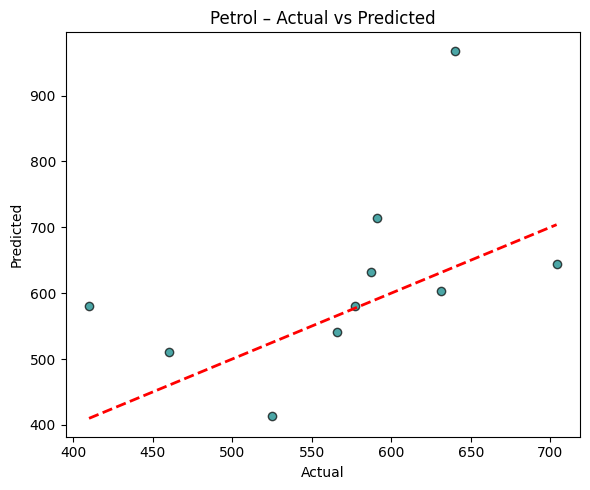

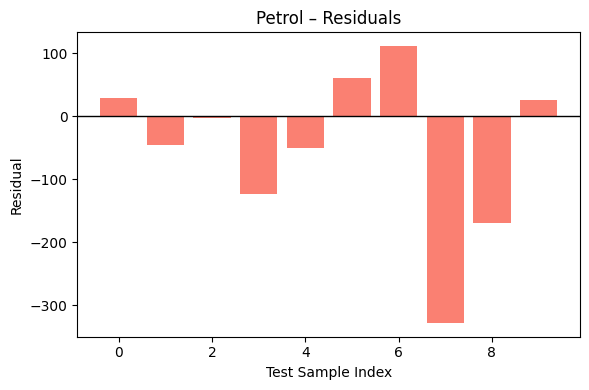

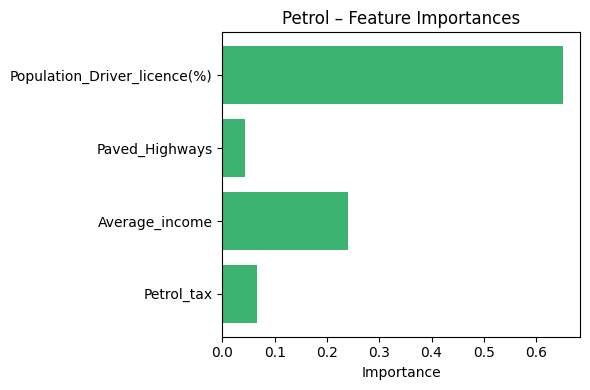

In [11]:
X_pet = petrol.drop("Petrol_Consumption", axis=1)
y_pet = petrol["Petrol_Consumption"]

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_pet, y_pet,
                                               test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_tr3, y_tr3)
y_pred3 = reg.predict(X_te3)

mae  = mean_absolute_error(y_te3, y_pred3)
mse  = mean_squared_error(y_te3, y_pred3)
rmse = np.sqrt(mse)

print("\n=== PETROL CONSUMPTION (Regression) ===")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Actual vs Predicted scatter
plt.figure(figsize=(6, 5))
plt.scatter(y_te3, y_pred3, color="teal", edgecolors="k", alpha=0.7)
plt.plot([y_te3.min(), y_te3.max()],
         [y_te3.min(), y_te3.max()], "r--", linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Petrol – Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residuals
residuals = y_te3 - y_pred3
plt.figure(figsize=(6, 4))
plt.bar(range(len(residuals)), residuals, color="salmon")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Test Sample Index")
plt.ylabel("Residual")
plt.title("Petrol – Residuals")
plt.tight_layout()
plt.show()

# Feature importances
plt.figure(figsize=(6, 4))
plt.barh(X_pet.columns, reg.feature_importances_, color="mediumseagreen")
plt.xlabel("Importance")
plt.title("Petrol – Feature Importances")
plt.tight_layout()
plt.show()